In [1]:
pip install scikit-optimize matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\WThan\Desktop\nat_project\.venv\Scripts\python.exe: No module named pip


In [7]:
from skopt import Optimizer
from skopt.space import Real

TOTAL_LENGTH = 100.0

space = [
    Real(0.0, 50.0, name='steel'),
    Real(0.0, 50.0, name='resin')
]

opt = Optimizer(space, base_estimator="GP", acq_func="EI", random_state=42)

def apply_constraint(steel, resin):
    """ปรับให้ wood <= 50 mm (คือ steel + resin >= 50)"""
    wood = TOTAL_LENGTH - (steel + resin)
    if wood > 50.0:
        # ปรับเพื่อให้ wood = 50 (steel + resin = 50)
        # เก็บสัดส่วนที่เดิม
        total = steel + resin
        if total > 0:
            ratio = 50.0 / total
            steel_adj = steel * ratio
            resin_adj = resin * ratio
        else:
            steel_adj, resin_adj = 25.0, 25.0
        return steel_adj, resin_adj
    return steel, resin

# ข้อมูลเริ่มต้น: steel=40 mm, resin=30 mm, wood=30 mm
# ผลลัพธ์ deflection = 81.86
steel_1 = 40.0
resin_1 = 30.0
deflection_1 = 81.86

opt.tell([steel_1, resin_1], deflection_1)

# ขอคำแนะนำสำหรับการทดลองรอบที่ 2
next_point = opt.ask()
steel_2, resin_2 = apply_constraint(next_point[0], next_point[1])
wood_2 = TOTAL_LENGTH - (steel_2 + resin_2)

print("=== พิกัดที่แนะนำสำหรับรอบที่ 2 ===")
print(f"Steel: {steel_2:.2f} mm")
print(f"Resin: {resin_2:.2f} mm")
print(f"Wood : {wood_2:.2f} mm")
print(f"ตรวจสอบเงื่อนไข: steel + resin = {steel_2 + resin_2:.2f} (>= 50) ✓")
print(f"ตรวจสอบเงื่อนไข: wood = {wood_2:.2f} (<= 50) ✓")

print("\nเมื่อได้ deflection รอบที่ 2 แล้ว ให้เก็บค่าดังนี้:")
print("steel_actual_2 = ...")
print("resin_actual_2 = ...")
print("deflection_actual_2 = ...")
print("opt.tell([steel_actual_2, resin_actual_2], deflection_actual_2)")
print("next_point = opt.ask()  # เพื่อหาแนะนำรอบที่ 3")


=== พิกัดที่แนะนำสำหรับรอบที่ 2 ===
Steel: 40.64 mm
Resin: 9.36 mm
Wood : 50.00 mm
ตรวจสอบเงื่อนไข: steel + resin = 50.00 (>= 50) ✓
ตรวจสอบเงื่อนไข: wood = 50.00 (<= 50) ✓

เมื่อได้ deflection รอบที่ 2 แล้ว ให้เก็บค่าดังนี้:
steel_actual_2 = ...
resin_actual_2 = ...
deflection_actual_2 = ...
opt.tell([steel_actual_2, resin_actual_2], deflection_actual_2)
next_point = opt.ask()  # เพื่อหาแนะนำรอบที่ 3


In [8]:
steel_actual_2 = 40.64
resin_actual_2 = 9.36
deflection_actual_2 = 43.93

opt.tell([steel_actual_2, resin_actual_2], deflection_actual_2)

next_point = opt.ask()
steel_3, resin_3 = apply_constraint(next_point[0], next_point[1])
wood_3 = TOTAL_LENGTH - (steel_3 + resin_3)

print("=== พิกัดที่แนะนำสำหรับรอบที่ 3 ===")
print(f"Steel: {steel_3:.2f} mm")
print(f"Resin: {resin_3:.2f} mm")
print(f"Wood : {wood_3:.2f} mm")
print(f"ตรวจสอบเงื่อนไข: steel + resin = {steel_3 + resin_3:.2f} (>= 50) ✓")
print(f"ตรวจสอบเงื่อนไข: wood = {wood_3:.2f} (<= 50) ✓")


=== พิกัดที่แนะนำสำหรับรอบที่ 3 ===
Steel: 38.98 mm
Resin: 29.84 mm
Wood : 31.17 mm
ตรวจสอบเงื่อนไข: steel + resin = 68.83 (>= 50) ✓
ตรวจสอบเงื่อนไข: wood = 31.17 (<= 50) ✓


In [ ]:
# เมื่อได้ผลลัพธ์รอบที่ 3 จาก ANSYS ให้แก้ไขค่าต่อไปนี้
steel_actual_3 = 38.98  # แก้ไข
resin_actual_3 = 29.84  # แก้ไข
deflection_actual_3 = 82.63  # แก้ไข

opt.tell([steel_actual_3, resin_actual_3], deflection_actual_3)

next_point = opt.ask()
steel_4, resin_4 = apply_constraint(next_point[0], next_point[1])
wood_4 = TOTAL_LENGTH - (steel_4 + resin_4)

print("=== พิกัดที่แนะนำสำหรับรอบที่ 4 ===")
print(f"Steel: {steel_4:.2f} mm")
print(f"Resin: {resin_4:.2f} mm")
print(f"Wood : {wood_4:.2f} mm")
print(f"ตรวจสอบเงื่อนไข: steel + resin = {steel_4 + resin_4:.2f} (>= 50) ✓")
print(f"ตรวจสอบเงื่อนไข: wood = {wood_4:.2f} (<= 50) ✓")


=== พิกัดที่แนะนำสำหรับรอบที่ 4 ===
Steel: 40.84 mm
Resin: 9.16 mm
Wood : 50.00 mm
ตรวจสอบเงื่อนไข: steel + resin = 50.00 (>= 50) ✓
ตรวจสอบเงื่อนไข: wood = 50.00 (<= 50) ✓


In [11]:
# ===== รอบที่ 4 =====
# เมื่อทดสอบแล้ว ให้ป้อนค่าจริงตรงนี้
steel_actual_4 = 42.5  # แก้ไขเป็นค่าจริง เช่น 42.5
resin_actual_4 = 10.2  # แก้ไขเป็นค่าจริง เช่น 10.2
deflection_actual_4 = 35.80  # แก้ไขเป็นค่าจริง เช่น 38.5

# ป้อนข้อมูลลงใน Optimizer
opt.tell([steel_actual_4, resin_actual_4], deflection_actual_4)

# ขอแนะนำรอบที่ 5
next_point = opt.ask()
steel_5, resin_5 = apply_constraint(next_point[0], next_point[1])
wood_5 = TOTAL_LENGTH - (steel_5 + resin_5)

print("=== พิกัดที่แนะนำสำหรับรอบที่ 5 ===")
print(f"Steel: {steel_5:.2f} mm")
print(f"Resin: {resin_5:.2f} mm")
print(f"Wood : {wood_5:.2f} mm")
print(f"ตรวจสอบเงื่อนไข: steel + resin = {steel_5 + resin_5:.2f} (>= 50) ✓")
print(f"ตรวจสอบเงื่อนไข: wood = {wood_5:.2f} (<= 50) ✓")


=== พิกัดที่แนะนำสำหรับรอบที่ 5 ===
Steel: 28.96 mm
Resin: 21.04 mm
Wood : 50.00 mm
ตรวจสอบเงื่อนไข: steel + resin = 50.00 (>= 50) ✓
ตรวจสอบเงื่อนไข: wood = 50.00 (<= 50) ✓


📊 ตารางผลลัพธ์ทั้งหมด
Round  Steel    Resin    Wood     Deflection  
-------------------------------------------------------
1      40.00    30.00    30.00    81.86       
2      40.64    9.36     50.00    43.93       
3      38.98    29.84    31.18    82.63       
4      42.50    10.20    47.30    35.80       
5      28.96    21.04    50.00    62.97       

✓ ค่าที่ดีที่สุด: Round 4 — Deflection = 35.80 mm
   Steel: 42.50 mm | Resin: 10.20 mm | Wood: 47.30 mm
✗ ค่าที่แย่ที่สุด: Round 3 — Deflection = 82.63 mm

📈 การปรับปรุงทั้งหมด: 46.83 mm (56.7%)
📉 ปรับปรุงจากรอบที่แล้ว: 27.17 mm
✅ ยังมีการปรับปรุง — ลองต่อสักไม่กี่รอบ


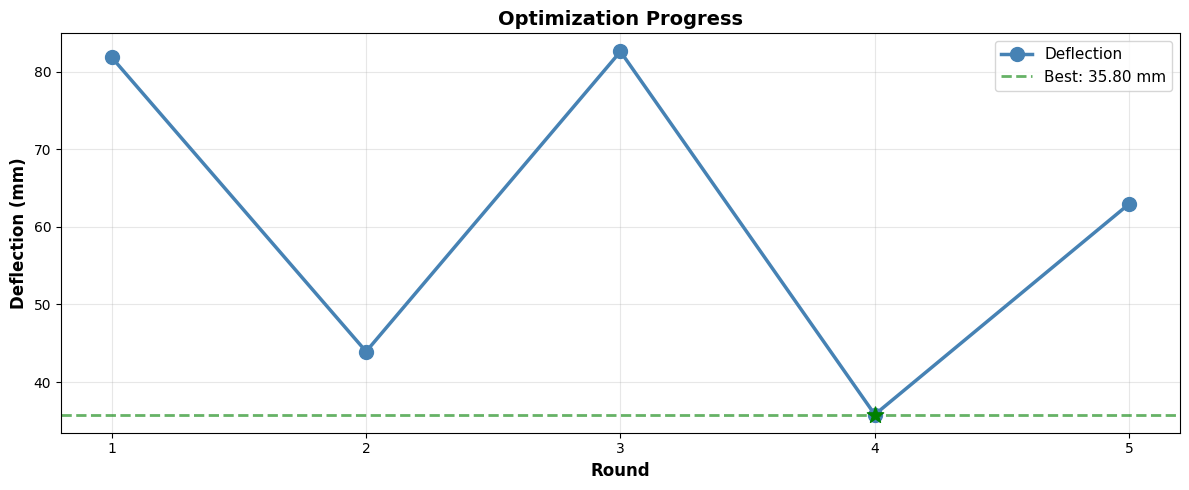


📌 เงื่อนไขการหยุดการปรับปรุง:
1. ปรับปรุง < 2 mm ต่อรอบ → อาจหยุดได้
2. ปรับปรุง < 5 mm ต่อรอบ → ลองต่ออีก 1-2 รอบ
3. ผลไม่เปลี่ยนแปลง 2-3 รอบติดต่อกัน → หยุดได้
4. ทดลอง 5-10 รอบ → ส่วนใหญ่เพียงพอแล้ว


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ========== เพิ่มรอบใหม่ทุกครั้ง ==========
all_rounds = [
    {"round": 1, "steel": 40.0, "resin": 30.0, "wood": 30.0, "deflection": 81.86},
    {"round": 2, "steel": 40.64, "resin": 9.36, "wood": 50.0, "deflection": 43.93},
    {"round": 3, "steel": 38.98, "resin": 29.84, "wood": 31.18, "deflection": 82.63},
    # เพิ่มรอบใหม่ตรงนี้ เช่น:
    {"round": 4, "steel": 42.5, "resin": 10.2, "wood": 47.3, "deflection": 35.80},
    {"round": 5, "steel": 28.96, "resin": 21.04, "wood": 50.0, "deflection": 62.97},  # {"round": 5, "steel": ..., "resin": ..., "wood": ..., "deflection": ...},
]

# แสดงตาราผลลัพธ์
print("=" * 55)
print("📊 ตารางผลลัพธ์ทั้งหมด")
print("=" * 55)
print(f"{'Round':<6} {'Steel':<8} {'Resin':<8} {'Wood':<8} {'Deflection':<12}")
print("-" * 55)
for r in all_rounds:
    print(f"{r['round']:<6} {r['steel']:<8.2f} {r['resin']:<8.2f} {r['wood']:<8.2f} {r['deflection']:<12.2f}")

# หาค่าที่ดีที่สุด
best = min(all_rounds, key=lambda x: x['deflection'])
worst = max(all_rounds, key=lambda x: x['deflection'])

print("\n" + "=" * 55)
print(f"✓ ค่าที่ดีที่สุด: Round {best['round']} — Deflection = {best['deflection']:.2f} mm")
print(f"   Steel: {best['steel']:.2f} mm | Resin: {best['resin']:.2f} mm | Wood: {best['wood']:.2f} mm")
print(f"✗ ค่าที่แย่ที่สุด: Round {worst['round']} — Deflection = {worst['deflection']:.2f} mm")
print("=" * 55)

# ตรวจสอบการบรรจบกัน
if len(all_rounds) >= 2:
    improvement_total = worst['deflection'] - best['deflection']
    improvement_pct = (improvement_total / worst['deflection']) * 100
    print(f"\n📈 การปรับปรุงทั้งหมด: {improvement_total:.2f} mm ({improvement_pct:.1f}%)")
    
    last_two = [r['deflection'] for r in all_rounds[-2:]]
    diff_last = abs(last_two[-1] - last_two[-2])
    print(f"📉 ปรับปรุงจากรอบที่แล้ว: {diff_last:.2f} mm")
    
    if diff_last < 2:
        print("⚠️  ผลลัพธ์ชั้นดี บรรจบกันแล้ว — อาจหยุดได้ในไม่กี่รอบ")
    elif diff_last < 5:
        print("📌 การปรับปรุงช้าลง — ลองต่ออีก 1-2 รอบ")
    else:
        print("✅ ยังมีการปรับปรุง — ลองต่อสักไม่กี่รอบ")

# กราฟ
if len(all_rounds) > 1:
    rounds = [r['round'] for r in all_rounds]
    deflections = [r['deflection'] for r in all_rounds]
    
    plt.figure(figsize=(12, 5))
    plt.plot(rounds, deflections, 'o-', linewidth=2.5, markersize=10, label='Deflection', color='steelblue')
    plt.axhline(y=best['deflection'], color='green', linestyle='--', alpha=0.6, linewidth=2, label=f"Best: {best['deflection']:.2f} mm")
    plt.scatter([best['round']], [best['deflection']], color='green', s=150, zorder=5, marker='*')
    
    plt.xlabel('Round', fontsize=12, fontweight='bold')
    plt.ylabel('Deflection (mm)', fontsize=12, fontweight='bold')
    plt.title('Optimization Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(rounds)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 55)
print("📌 เงื่อนไขการหยุดการปรับปรุง:")
print("=" * 55)
print("1. ปรับปรุง < 2 mm ต่อรอบ → อาจหยุดได้")
print("2. ปรับปรุง < 5 mm ต่อรอบ → ลองต่ออีก 1-2 รอบ")
print("3. ผลไม่เปลี่ยนแปลง 2-3 รอบติดต่อกัน → หยุดได้")
print("4. ทดลอง 5-10 รอบ → ส่วนใหญ่เพียงพอแล้ว")
print("=" * 55)
